# Assignment 3 EDA


## 1. Setup

In [1]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 50)

DB_PATH = Path("steam_games_reviews_25.sqlite")
assert DB_PATH.exists(), f"Database not found at {DB_PATH.resolve()}"

con = sqlite3.connect(DB_PATH)
print(f"Using database: {DB_PATH.resolve()}")

Using database: C:\Users\heloi\OneDrive - KU Leuven\EMOS\adv analytics BD\assignment 3\steam_games_reviews_25.sqlite


## 2. Inspect the schema

In [2]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name",
    con,
)
tables

,name
0,games
1,reviews


data set has 2 tables
1. games: metadata
2. reviews: user generated text & review signals

In [3]:
def pragma_table_info(table_name: str) -> pd.DataFrame:
    return pd.read_sql_query(f"PRAGMA table_info({table_name})", con)

games_schema = pragma_table_info("games")
reviews_schema = pragma_table_info("reviews")

display(games_schema)
display(reviews_schema)

,cid,name,type,notnull,dflt_value,pk
0,0,appid,INTEGER,0,None,1
1,1,name,TEXT,0,None,0
2,2,release_date,TEXT,0,None,0
3,3,required_age,INTEGER,0,None,0
4,4,price,REAL,0,None,0
5,5,dlc_count,INTEGER,0,None,0
6,6,detailed_description,TEXT,0,None,0
7,7,about_the_game,TEXT,0,None,0
8,8,short_description,TEXT,0,None,0
9,9,reviews_summary,TEXT,0,None,0


,cid,name,type,notnull,dflt_value,pk
0,0,recommendationid,TEXT,0,None,1
1,1,appid,INTEGER,1,None,0
2,2,language,TEXT,0,None,0
3,3,review,TEXT,0,None,0
4,4,timestamp_created,INTEGER,0,None,0
5,5,timestamp_updated,INTEGER,0,None,0
6,6,voted_up,INTEGER,0,None,0
7,7,votes_up,INTEGER,0,None,0
8,8,votes_funny,INTEGER,0,None,0
9,9,weighted_vote_score,TEXT,0,None,0


## 3. Basic table sizes

In [4]:
counts = pd.read_sql_query(
    """
    SELECT 'games' AS table_name, COUNT(*) AS n_rows FROM games
    UNION ALL
    SELECT 'reviews' AS table_name, COUNT(*) AS n_rows FROM reviews
    """,
    con,
)
counts

,table_name,n_rows
0,games,39176
1,reviews,7679845


## 4. Preview a few rows

In [5]:
games_preview = pd.read_sql_query(
    """
    SELECT appid, name, release_date, price, short_description, genres_json, tags_json
    FROM games
    LIMIT 5
    """,
    con,
)
games_preview

,appid,name,release_date,price,short_description,genres_json,tags_json
0,10,Counter-Strike,"Nov 1, 2000",9.99,Play the world's number 1 online action game. Engage in an incredibly realistic brand of terrorist warfare in this w...,"[""Action""]","{""Action"": 5504, ""FPS"": 4929, ""Multiplayer"": 3474, ""Shooter"": 3419, ""Classic"": 2849, ""Team-Based"": 1921, ""First-Pers..."
1,20,Team Fortress Classic,"Apr 1, 1999",4.99,"One of the most popular online action games of all time, Team Fortress Classic features over nine character classes ...","[""Action""]","{""Action"": 767, ""FPS"": 333, ""Multiplayer"": 280, ""Classic"": 254, ""Hero Shooter"": 226, ""Shooter"": 224, ""Team-Based"": 2..."
2,30,Day of Defeat,"May 1, 2003",4.99,Enlist in an intense brand of Axis vs. Allied teamplay set in the WWII European Theatre of Operations. Players assum...,"[""Action""]","{""FPS"": 804, ""World War II"": 272, ""Multiplayer"": 216, ""Shooter"": 194, ""Action"": 165, ""War"": 159, ""Team-Based"": 140, ..."
3,40,Deathmatch Classic,"Jun 1, 2001",4.99,Enjoy fast-paced multiplayer gaming with Deathmatch Classic (a.k.a. DMC). Valve's tribute to the work of id software...,"[""Action""]","{""Action"": 638, ""FPS"": 155, ""Classic"": 119, ""Multiplayer"": 109, ""Shooter"": 103, ""First-Person"": 83, ""Arena Shooter"":..."
4,50,Half-Life: Opposing Force,"Nov 1, 1999",4.99,Return to the Black Mesa Research Facility as one of the military specialists assigned to eliminate Gordon Freeman. ...,"[""Action""]","{""FPS"": 934, ""Action"": 362, ""Classic"": 291, ""Sci-fi"": 285, ""Singleplayer"": 267, ""Shooter"": 251, ""First-Person"": 222,..."


In [6]:
reviews_preview = pd.read_sql_query(
    """
    SELECT recommendationid, appid, language, voted_up, votes_up, weighted_vote_score, review
    FROM reviews
    LIMIT 5
    """,
    con,
)
reviews_preview

,recommendationid,appid,language,voted_up,votes_up,weighted_vote_score,review
0,223036085,10,english,1,0,0.5,better than cs2\r\n
1,223015211,10,english,1,0,0.5,amazing
2,222991906,10,english,1,0,0.5,legend for 2008
3,222984439,10,english,1,0,0.5,Extremely simple game and yet it is also extremely enjoyable. Graphics do not affect the overall gameplay experience...
4,222970777,10,english,1,0,0.5,LEGEND GAME


## 5. Missingness in the most useful game columns

In [7]:
games = pd.read_sql_query(
    """
    SELECT
        appid,
        name,
        short_description,
        about_the_game,
        detailed_description,
        release_date,
        price,
        reviews_summary,
        developers_json,
        publishers_json,
        categories_json,
        genres_json,
        tags_json,
        windows,
        mac,
        linux,
        recommendations,
        metacritic_score,
        positive,
        negative,
        average_playtime_forever,
        peak_ccu
    FROM games
    """,
    con,
)

def empty_or_null_rate(series: pd.Series) -> float:
    s = series.fillna("") if series.dtype == "object" else series
    if series.dtype == "object":
        return ((s.astype(str).str.strip() == "") | series.isna()).mean()
    return series.isna().mean()

missing_report = pd.DataFrame({
    "column": games.columns,
    "missing_or_empty_pct": [empty_or_null_rate(games[c]) * 100 for c in games.columns],
})

missing_report.sort_values("missing_or_empty_pct", ascending=False).reset_index(drop=True)

,column,missing_or_empty_pct
0,appid,0.0
1,name,0.0
2,short_description,0.0
3,about_the_game,0.0
4,detailed_description,0.0
5,release_date,0.0
6,price,0.0
7,reviews_summary,0.0
8,developers_json,0.0
9,publishers_json,0.0


## 6. Text field lengths

In [8]:
text_cols = ["name", "short_description", "about_the_game", "detailed_description", "reviews_summary"]

length_stats = []
for col in text_cols:
    lengths = games[col].fillna("").astype(str).str.len()
    length_stats.append({
        "column": col,
        "mean_len": lengths.mean(),
        "median_len": lengths.median(),
        "p90_len": lengths.quantile(0.9),
        "max_len": lengths.max(),
    })

pd.DataFrame(length_stats).sort_values("mean_len", ascending=False)

,column,mean_len,median_len,p90_len,max_len
3,detailed_description,1541.283515,1295.0,2760.0,67521
2,about_the_game,1497.251965,1269.0,2664.0,67521
1,short_description,209.658592,223.0,294.0,342
4,reviews_summary,82.177838,0.0,350.0,3232
0,name,18.336890,16.0,32.0,135


short description, good for retrieval
detailed description/about the game => often v long => truncation?

review summary median = 0 => often missing, not v reliable

## 7. Parse genres, categories, and tags

In [10]:
def parse_json_or_default(value, default):
    if value is None or value == "":
        return default
    try:
        return json.loads(value)
    except Exception:
        return default

games["genres"] = games["genres_json"].apply(lambda x: parse_json_or_default(x, []))
games["categories"] = games["categories_json"].apply(lambda x: parse_json_or_default(x, []))
games["tags"] = games["tags_json"].apply(lambda x: parse_json_or_default(x, {}))

games[["name", "genres", "categories", "tags"]].head(3)

,name,genres,categories,tags
0,Counter-Strike,[Action],"[Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Color Alternatives, Custom Volume Controls, Keyboard Only O...","{'Action': 5504, 'FPS': 4929, 'Multiplayer': 3474, 'Shooter': 3419, 'Classic': 2849, 'Team-Based': 1921, 'First-Pers..."
1,Team Fortress Classic,[Action],"[Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Custom Volume Controls, Keyboard Only Option, Stereo Sound,...","{'Action': 767, 'FPS': 333, 'Multiplayer': 280, 'Classic': 254, 'Hero Shooter': 226, 'Shooter': 224, 'Team-Based': 2..."
2,Day of Defeat,[Action],"[Multi-player, Camera Comfort, Color Alternatives, Custom Volume Controls, Stereo Sound, Valve Anti-Cheat enabled, F...","{'FPS': 804, 'World War II': 272, 'Multiplayer': 216, 'Shooter': 194, 'Action': 165, 'War': 159, 'Team-Based': 140, ..."


In [11]:
genre_counts = (
    games[["appid", "genres"]]
    .explode("genres")
    .dropna()
    .groupby("genres")
    .size()
    .sort_values(ascending=False)
    .head(20)
)
genre_counts

genres
Indie                    27225
Adventure                16717
Action                   16190
Casual                   14448
Simulation                9867
RPG                       8110
Strategy                  8083
Free To Play              5547
Early Access              3114
Sports                    1685
Racing                    1312
Massively Multiplayer     1206
Violent                    127
Gore                        78
Sexual Content              33
Nudity                      33
Game Development             7
Utilities                    7
Education                    6
Design & Illustration        6
dtype: int64

strong imbalance, broad dominate

C:\Users\heloi\AppData\Local\Temp\ipykernel_24228\2998661984.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")


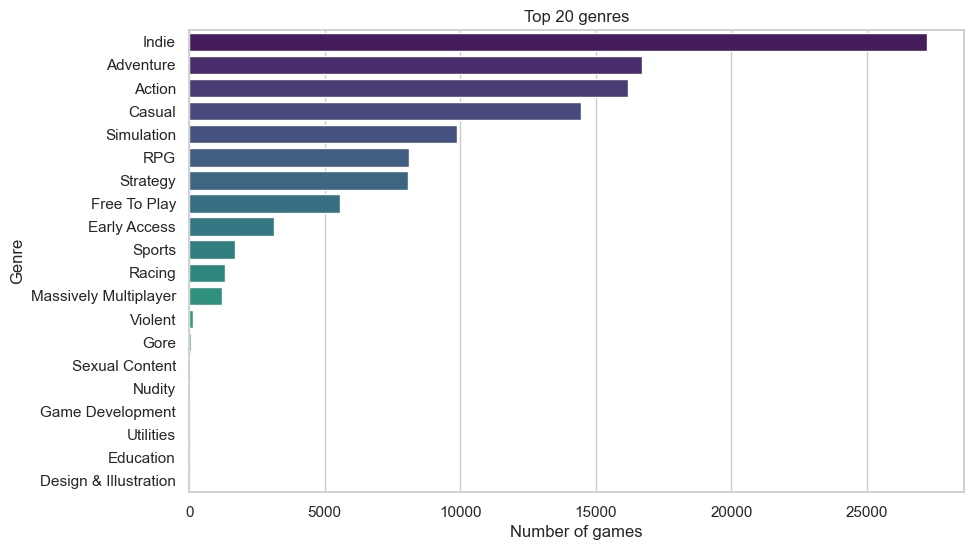

In [12]:
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette="viridis")
plt.title("Top 20 genres")
plt.xlabel("Number of games")
plt.ylabel("Genre")
plt.show()

In [14]:
tag_counts = {}

for tag_value in games["tags"]:
    if isinstance(tag_value, dict):
        for tag, score in tag_value.items():
            tag_counts[tag] = tag_counts.get(tag, 0) + 1
    elif isinstance(tag_value, list):
        for tag in tag_value:
            tag_counts[tag] = tag_counts.get(tag, 0) + 1

top_tags = pd.Series(tag_counts).sort_values(ascending=False).head(25)
top_tags


Singleplayer          19141
Indie                 17947
Adventure             14151
Action                14134
Casual                11710
2D                     9080
Simulation             7911
Atmospheric            7660
Strategy               7233
RPG                    6677
Story Rich             6637
Puzzle                 6114
Multiplayer            5966
Exploration            5508
3D                     5479
First-Person           5301
Pixel Graphics         5101
Cute                   4729
Colorful               4708
Fantasy                4519
Funny                  4505
Horror                 4429
Anime                  3896
Female Protagonist     3867
Sci-fi                 3617
dtype: int64

C:\Users\heloi\AppData\Local\Temp\ipykernel_24228\137753229.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tags.values, y=top_tags.index, palette="magma")


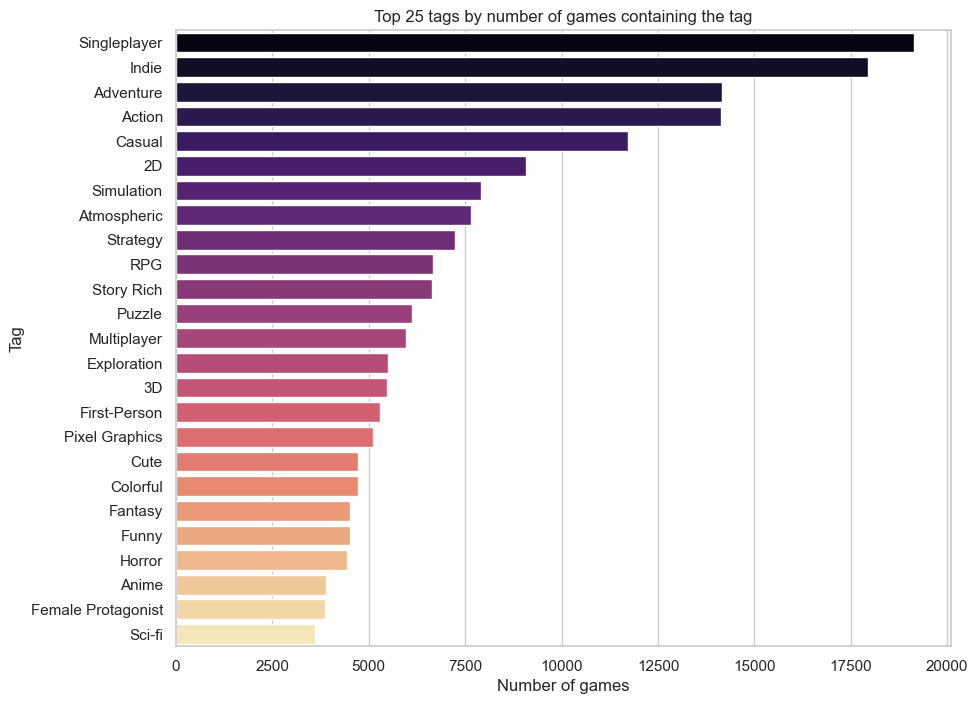

In [15]:
plt.figure(figsize=(10, 8))
sns.barplot(x=top_tags.values, y=top_tags.index, palette="magma")
plt.title("Top 25 tags by number of games containing the tag")
plt.xlabel("Number of games")
plt.ylabel("Tag")
plt.show()

## 8. Review coverage and review quality

In [16]:
reviews = pd.read_sql_query(
    """
    SELECT
        recommendationid,
        appid,
        language,
        review,
        voted_up,
        votes_up,
        votes_funny,
        weighted_vote_score,
        comment_count,
        steam_purchase,
        received_for_free,
        written_during_early_access,
        primarily_steam_deck,
        refunded,
        timestamp_created
    FROM reviews
    """,
    con,
)

reviews["review_len"] = reviews["review"].fillna("").astype(str).str.len()
reviews["weighted_vote_score"] = pd.to_numeric(reviews["weighted_vote_score"], errors="coerce")

reviews.head()

,recommendationid,appid,language,review,voted_up,votes_up,votes_funny,weighted_vote_score,comment_count,steam_purchase,received_for_free,written_during_early_access,primarily_steam_deck,refunded,timestamp_created,review_len
0,223036085,10,english,better than cs2\r\n,1,0,0,0.5,0,1,0,0,0,0,1775926201,17
1,223015211,10,english,amazing,1,0,0,0.5,0,0,0,0,0,0,1775908677,7
2,222991906,10,english,legend for 2008,1,0,0,0.5,0,1,0,0,0,0,1775879493,15
3,222984439,10,english,Extremely simple game and yet it is also extremely enjoyable. Graphics do not affect the overall gameplay experience...,1,0,0,0.5,0,1,0,0,0,0,1775869746,181
4,222970777,10,english,LEGEND GAME,1,0,0,0.5,0,1,0,0,0,0,1775853458,11


In [17]:
review_coverage = pd.read_sql_query(
    """
    SELECT appid, COUNT(*) AS n_reviews
    FROM reviews
    GROUP BY appid
    """,
    con,
)

review_coverage["n_reviews"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99])

count    39272.000000
mean       195.555230
std        184.046611
min          1.000000
25%         44.000000
50%        101.000000
75%        369.000000
90%        500.000000
99%        500.000000
max        500.000000
Name: n_reviews, dtype: float64

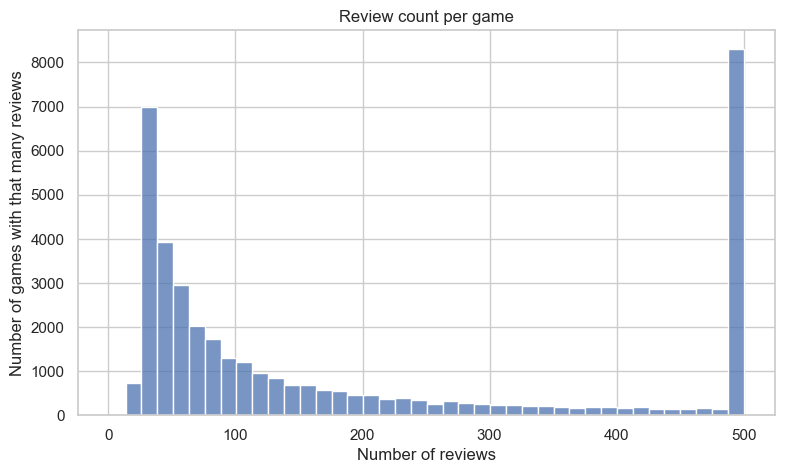

In [22]:
plt.figure(figsize=(9, 5))
sns.histplot(review_coverage["n_reviews"], bins=40)
plt.title("Review count per game")
plt.xlabel("Number of reviews")
plt.ylabel("Number of games with that many reviews")
plt.show()

number of reviews varies a lot per game

In [19]:
reviews[["review_len", "voted_up", "votes_up", "weighted_vote_score"]].describe()

,review_len,voted_up,votes_up,weighted_vote_score
count,7.679845e+06,7.679845e+06,7.679845e+06,7.679845e+06
mean,3.765049e+02,7.973005e-01,3.296281e+00,5.112248e-01
std,3.559722e+03,4.020105e-01,1.730195e+01,6.052934e-02
min,0.000000e+00,0.000000e+00,0.000000e+00,1.280826e-03
25%,3.700000e+01,1.000000e+00,0.000000e+00,5.000000e-01
50%,1.250000e+02,1.000000e+00,1.000000e+00,5.000000e-01
75%,3.720000e+02,1.000000e+00,2.000000e+00,5.206517e-01
max,9.638999e+06,1.000000e+00,1.762600e+04,9.920363e-01


In [28]:
mean_voted_up = reviews["voted_up"].mean()
mean_voted_up

np.float64(0.7973004663505578)

around 80% reviews are useful
review length very skewed
=> filtered/summarise reviews? top positive reviews? top helful reviews?

In [20]:
reviews["language"].value_counts(dropna=False).head(10)

language
english      7679824
russian            5
latam              4
schinese           3
italian            3
french             2
german             1
tchinese           1
turkish            1
brazilian          1
Name: count, dtype: int64

reasonable to drop non-english reviews
(latam = latin american spanish)

In [38]:
sample_review_rows = pd.read_sql_query(
    """
    SELECT r.appid, g.name, r.voted_up, r.votes_up, r.review
    FROM reviews r
    JOIN games g ON g.appid = r.appid
    WHERE r.review IS NOT NULL AND TRIM(r.review) != ''
    ORDER BY RANDOM()
    LIMIT 10
    """,
    con,
)
sample_review_rows

,appid,name,voted_up,votes_up,review
0,2137700,I'm on Observation Duty 6,0,0,Disappointed with this one. Didn't have the same charm as the previous ones and didn't feel as scary. Get the other ones instead.
1,417910,Street Warriors Online,1,0,good game
2,2569510,MLB 9 Innings Rivals 26,1,5,"good game, fun fantasy team sim, wish we had the show on pc but ay this the next best thing"
3,893050,Hasbro's BATTLESHIP,0,1,"Love this game! I love when it updates and breaks completely! IT's actually sick and awesome. I love not being able to play with my friends anymore - who needs them anyway, just give me one of the bots from online to play against forever. I definitely hope they do NOT fix this soon"
4,278460,Skyborn,1,2,"Looks like a typical RPG Pixel game~ \nBut you can't deny the fact that the game is Fun,Epic,Adventureous and relaxing at the same time. The map is also big and there's an Okay-ish level of interaction around the map. The only con I would say is that it doesn't have a mini-map or a map for you to look for directions, so you can get lost pretty easily. Other than that, I highly recommend it ~"
5,266230,Last Dream,1,0,"One of my favorite retro RPGs. Great storyline, classic turn-based battle and exceptional music. If you like Final Fantasy 1 and 4 you'll dig it."
6,2834700,Koltera 2,0,3,"Extremely grindy and obtuse with the descriptions. Takes DAYS to create the items to summon 1 creature down the line. To summon all takes way too much time for what you are doing.\nIn its current state, I can't recommend. There are better free incremental games that respect your time."
7,1140270,Monster Prom 2: Monster Camp,1,0,Moss Mann for the win
8,1320100,Wanted Raccoon,1,0,10/10\ni broke into a man's house and caused a flood after taking the gardeners hostage
9,2061440,Oxygen: First Breath,1,0,LIKE IT!!!1


In [30]:
pd.set_option("display.max_colwidth", None)

## 9. Join game metadata with review coverage

This is useful for deciding whether reviews are worth using in ranking or answer generation.

In [23]:
games_with_reviews = games.merge(review_coverage, on="appid", how="left")
games_with_reviews["n_reviews"] = games_with_reviews["n_reviews"].fillna(0)

games_with_reviews[["name", "recommendations", "positive", "negative", "n_reviews"]].head()

,name,recommendations,positive,negative,n_reviews
0,Counter-Strike,167314,243818,6427,500.0
1,Team Fortress Classic,6881,7602,1136,500.0
2,Day of Defeat,4417,6414,688,500.0
3,Deathmatch Classic,2402,2618,545,500.0
4,Half-Life: Opposing Force,24360,24363,1198,500.0


potential ranking logic: prefer games w a lot of reviews

## 10. Build a candidate text field for retrieval

example of text we could embed for retrieval?

In [25]:
def top_k_tags(tag_dict, k=8):
    if not isinstance(tag_dict, dict) or len(tag_dict) == 0:
        return []
    return [tag for tag, _ in sorted(tag_dict.items(), key=lambda x: x[1], reverse=True)[:k]]

games_with_reviews["top_tags"] = games_with_reviews["tags"].apply(top_k_tags)
games_with_reviews["retrieval_text"] = (
    "Name: " + games_with_reviews["name"].fillna("") + "\n"
    + "Genres: " + games_with_reviews["genres"].apply(lambda x: ", ".join(x) if isinstance(x, list) else "") + "\n"
    + "Categories: " + games_with_reviews["categories"].apply(lambda x: ", ".join(x[:8]) if isinstance(x, list) else "") + "\n"
    + "Tags: " + games_with_reviews["top_tags"].apply(lambda x: ", ".join(x)) + "\n"
    + "Short description: " + games_with_reviews["short_description"].fillna("") + "\n"
    + "About: " + games_with_reviews["about_the_game"].fillna("").str.slice(0, 700)
)

games_with_reviews[["name", "retrieval_text"]].head(3)

,name,retrieval_text
0,Counter-Strike,"Name: Counter-Strike\nGenres: Action\nCategories: Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Color Alte..."
1,Team Fortress Classic,"Name: Team Fortress Classic\nGenres: Action\nCategories: Multi-player, PvP, Online PvP, Shared/Split Screen PvP, Cus..."
2,Day of Defeat,"Name: Day of Defeat\nGenres: Action\nCategories: Multi-player, Camera Comfort, Color Alternatives, Custom Volume Con..."


- useful game fields for retrieval: name, short_Desc, about_the_game, genres, categories, top tags
- reviews: useful for ranking/answer generation
- long descriptions & many reviews => truncation before sending them to LLM
